# cloudposterior: Eight Schools Demo

Run PyMC MCMC sampling on cloud VMs with one line of code. Results are cached to disk so re-running is instant.

In [1]:
import numpy as np
import pymc as pm
import arviz as az

import cloudposterior as cp

## Data

The classic Eight Schools dataset from Rubin (1981). Eight schools administered coaching programs, and the effects (with standard errors) were estimated for each.

In [2]:
y = np.array([28, 8, -3, 7, -1, 1, 18, 12], dtype=np.float64)
sigma = np.array([15, 10, 16, 11, 9, 11, 10, 18], dtype=np.float64)
schools = ["A", "B", "C", "D", "E", "F", "G", "H"]

## Model

Non-centered parameterization of the hierarchical model to reduce divergences.

In [3]:
with pm.Model(coords={"school": schools}) as eight_schools:
    # Hyperpriors
    mu = pm.Normal("mu", mu=0, sigma=5)
    tau = pm.HalfCauchy("tau", beta=5)

    # Non-centered parameterization
    theta_raw = pm.Normal("theta_raw", mu=0, sigma=1, dims="school")
    theta = pm.Deterministic("theta", mu + tau * theta_raw, dims="school")

    # Likelihood
    pm.Normal("obs", mu=theta, sigma=sigma, observed=y, dims="school")

## Sample remotely on Modal

Wrap the model with `cp.wrap()`. Disk caching is enabled so re-running this cell returns instantly. Remote execution ships the model to a cloud VM.

In [4]:
with cp.wrap(eight_schools, remote=True, cache="disk"):
    idata = pm.sample(draws=2000, tune=1000, chains=4)

## Diagnostics

In [5]:
az.summary(idata, var_names=["mu", "tau", "theta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,4.344,3.314,-1.623,10.783,0.038,0.042,7437.0,4390.0,1.0
tau,3.542,3.102,0.000,9.117,0.044,0.055,4241.0,3655.0,1.0
theta[A],6.188,5.402,-3.497,16.772,0.068,0.080,6735.0,5499.0,1.0
theta[B],4.874,4.732,-4.435,13.577,0.051,0.060,8851.0,5852.0,1.0
theta[C],3.814,5.279,-6.005,13.617,0.064,0.090,7612.0,5372.0,1.0
theta[D],4.753,4.680,-4.345,13.446,0.050,0.061,8838.0,5860.0,1.0
theta[E],3.558,4.608,-5.627,11.767,0.051,0.060,8666.0,5716.0,1.0
theta[F],3.942,4.790,-5.785,12.746,0.053,0.065,8436.0,5760.0,1.0
theta[G],6.188,5.073,-3.056,16.018,0.058,0.068,8049.0,5781.0,1.0
theta[H],4.872,5.317,-5.040,15.230,0.060,0.084,8180.0,5496.0,1.0


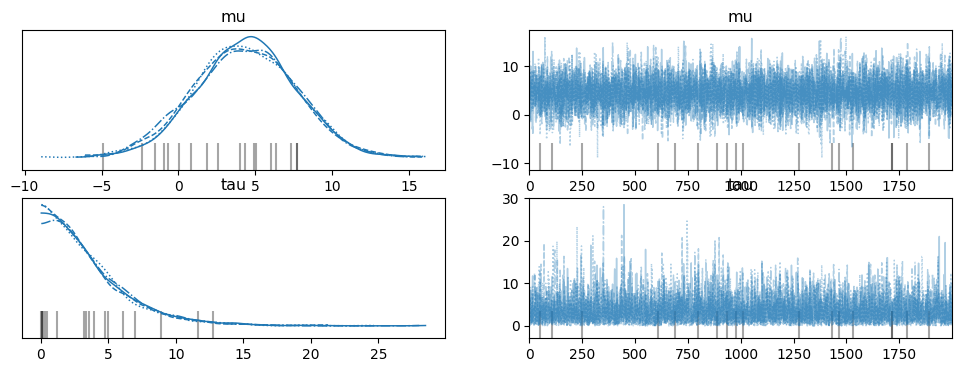

In [6]:
az.plot_trace(idata, var_names=["mu", "tau"]);

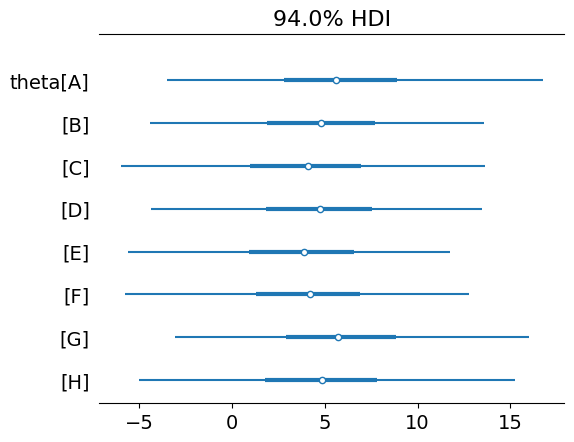

In [7]:
az.plot_forest(idata, var_names=["theta"], combined=True, hdi_prob=0.94);

## Compare: local with caching

Run the same model locally with disk caching. First run samples normally; re-running returns the cached result instantly.

In [8]:
with cp.wrap(eight_schools, cache="disk"):
    idata_local = pm.sample(draws=2000, tune=1000, chains=4)

az.summary(idata_local, var_names=["mu", "tau", "theta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,4.344,3.314,-1.623,10.783,0.038,0.042,7437.0,4390.0,1.0
tau,3.542,3.102,0.000,9.117,0.044,0.055,4241.0,3655.0,1.0
theta[A],6.188,5.402,-3.497,16.772,0.068,0.080,6735.0,5499.0,1.0
theta[B],4.874,4.732,-4.435,13.577,0.051,0.060,8851.0,5852.0,1.0
theta[C],3.814,5.279,-6.005,13.617,0.064,0.090,7612.0,5372.0,1.0
theta[D],4.753,4.680,-4.345,13.446,0.050,0.061,8838.0,5860.0,1.0
theta[E],3.558,4.608,-5.627,11.767,0.051,0.060,8666.0,5716.0,1.0
theta[F],3.942,4.790,-5.785,12.746,0.053,0.065,8436.0,5760.0,1.0
theta[G],6.188,5.073,-3.056,16.018,0.058,0.068,8049.0,5781.0,1.0
theta[H],4.872,5.317,-5.040,15.230,0.060,0.084,8180.0,5496.0,1.0
